In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import os
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"ayurveda_psychology_wellness_dataset.csv")
df

,patient_id,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,...,diet_type,caffeine_intake,screen_time_hours,prakriti,vikriti,herbs,diet_advice,duration_days,improvement_score,side_effects
0,P001,37,Female,9,10,4,8,9,2,10,...,Balanced,0,4,Pitta,Vata Aggravation,"['Ashwagandha', 'Guduchi']","Light diet, avoid fried foods",14,68,True
1,P002,40,Other,1,7,8,7,8,2,4,...,Spicy,2,2,Kapha,Vata Aggravation,"['Triphala', 'Guduchi']","Warm milk, early dinner",21,58,True
2,P003,32,Female,4,1,6,10,9,10,2,...,Spicy,1,10,Pitta-Kapha,Vata Aggravation,"['Ashwagandha', 'Guduchi']","Cooling foods, avoid spicy",14,91,False
3,P004,53,Female,1,2,2,4,8,5,7,...,Balanced,5,5,Vata-Kapha,Vata Aggravation,"['Brahmi', 'Jatamansi']","Warm milk, early dinner",21,92,False
4,P005,48,Female,7,2,10,1,1,3,2,...,Light,1,2,Vata,Pitta Aggravation,"['Brahmi', 'Ashwagandha']","Light diet, avoid fried foods",28,93,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1616,P117,52,Male,6,4,3,7,8,10,9,...,Light,2,10,Vata-Pitta,Balanced,"['Triphala', 'Guduchi']","Cooling foods, avoid spicy",21,82,True
1617,P118,69,Male,2,1,1,9,4,6,6,...,Balanced,3,8,Pitta,Pitta Aggravation,"['Brahmi', 'Jatamansi']",Balanced diet,15,80,True
1618,P119,23,Female,4,9,2,6,4,2,6,...,Spicy,4,9,Kapha,Balanced,"['Brahmi', 'Ashwagandha']","Light diet, avoid fried foods",28,61,False
1619,P120,66,Female,5,8,10,7,1,3,10,...,Light,4,6,Pitta-Kapha,Balanced,"['Triphala', 'Guduchi']","Cooling foods, avoid spicy",21,58,False


In [5]:
df.columns


Index(['patient_id', 'age', 'gender', 'stress_level', 'anxiety_level',
       'depression_score', 'maslow_physiological', 'maslow_safety',
       'maslow_social', 'maslow_esteem', 'maslow_self_actualization',
       'sleep_hours', 'exercise_frequency', 'diet_type', 'caffeine_intake',
       'screen_time_hours', 'prakriti', 'vikriti', 'herbs', 'diet_advice',
       'duration_days', 'improvement_score', 'side_effects'],
      dtype='object')

In [6]:
df.isnull().sum()

patient_id                   0
age                          0
gender                       0
stress_level                 0
anxiety_level                0
depression_score             0
maslow_physiological         0
maslow_safety                0
maslow_social                0
maslow_esteem                0
maslow_self_actualization    0
sleep_hours                  0
exercise_frequency           0
diet_type                    0
caffeine_intake              0
screen_time_hours            0
prakriti                     0
vikriti                      0
herbs                        0
diet_advice                  0
duration_days                0
improvement_score            0
side_effects                 0
dtype: int64

In [7]:
df.describe()


,age,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,maslow_self_actualization,sleep_hours,exercise_frequency,caffeine_intake,screen_time_hours,duration_days,improvement_score
count,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000,1621.000000
mean,44.250463,5.644664,5.489204,5.186922,5.537323,5.417027,5.606416,5.501542,5.479951,6.061690,3.303516,2.534855,5.999383,19.874769,72.639112
std,15.545678,2.890312,2.788763,3.249156,2.881721,2.903392,2.914088,2.880463,2.810540,1.976065,2.303335,1.644910,2.599976,5.562306,13.742290
min,18.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.000000,0.000000,2.000000,14.000000,50.000000
25%,31.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,1.000000,1.000000,4.000000,15.000000,60.000000
50%,44.000000,6.000000,6.000000,5.000000,5.000000,5.000000,6.000000,6.000000,5.000000,6.000000,3.000000,3.000000,6.000000,21.000000,73.000000
75%,58.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,5.000000,4.000000,8.000000,28.000000,85.000000
max,70.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,7.000000,5.000000,10.000000,28.000000,95.000000


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1621 entries, 0 to 1620
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   patient_id                 1621 non-null   object
 1   age                        1621 non-null   int64 
 2   gender                     1621 non-null   object
 3   stress_level               1621 non-null   int64 
 4   anxiety_level              1621 non-null   int64 
 5   depression_score           1621 non-null   int64 
 6   maslow_physiological       1621 non-null   int64 
 7   maslow_safety              1621 non-null   int64 
 8   maslow_social              1621 non-null   int64 
 9   maslow_esteem              1621 non-null   int64 
 10  maslow_self_actualization  1621 non-null   int64 
 11  sleep_hours                1621 non-null   int64 
 12  exercise_frequency         1621 non-null   int64 
 13  diet_type                  1621 non-null   object
 14  caffeine

In [9]:
df.head()

,patient_id,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,...,diet_type,caffeine_intake,screen_time_hours,prakriti,vikriti,herbs,diet_advice,duration_days,improvement_score,side_effects
0,P001,37,Female,9,10,4,8,9,2,10,...,Balanced,0,4,Pitta,Vata Aggravation,"['Ashwagandha', 'Guduchi']","Light diet, avoid fried foods",14,68,True
1,P002,40,Other,1,7,8,7,8,2,4,...,Spicy,2,2,Kapha,Vata Aggravation,"['Triphala', 'Guduchi']","Warm milk, early dinner",21,58,True
2,P003,32,Female,4,1,6,10,9,10,2,...,Spicy,1,10,Pitta-Kapha,Vata Aggravation,"['Ashwagandha', 'Guduchi']","Cooling foods, avoid spicy",14,91,False
3,P004,53,Female,1,2,2,4,8,5,7,...,Balanced,5,5,Vata-Kapha,Vata Aggravation,"['Brahmi', 'Jatamansi']","Warm milk, early dinner",21,92,False
4,P005,48,Female,7,2,10,1,1,3,2,...,Light,1,2,Vata,Pitta Aggravation,"['Brahmi', 'Ashwagandha']","Light diet, avoid fried foods",28,93,True


In [10]:
df.tail()


,patient_id,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,...,diet_type,caffeine_intake,screen_time_hours,prakriti,vikriti,herbs,diet_advice,duration_days,improvement_score,side_effects
1616,P117,52,Male,6,4,3,7,8,10,9,...,Light,2,10,Vata-Pitta,Balanced,"['Triphala', 'Guduchi']","Cooling foods, avoid spicy",21,82,True
1617,P118,69,Male,2,1,1,9,4,6,6,...,Balanced,3,8,Pitta,Pitta Aggravation,"['Brahmi', 'Jatamansi']",Balanced diet,15,80,True
1618,P119,23,Female,4,9,2,6,4,2,6,...,Spicy,4,9,Kapha,Balanced,"['Brahmi', 'Ashwagandha']","Light diet, avoid fried foods",28,61,False
1619,P120,66,Female,5,8,10,7,1,3,10,...,Light,4,6,Pitta-Kapha,Balanced,"['Triphala', 'Guduchi']","Cooling foods, avoid spicy",21,58,False
1620,P121,64,Other,1,6,10,5,4,3,2,...,Spicy,0,7,Vata,Vata Aggravation,"['Triphala', 'Guduchi']","Cooling foods, avoid spicy",14,78,True


In [11]:
df.prakriti.unique()

array(['Pitta', 'Kapha', 'Pitta-Kapha', 'Vata-Kapha', 'Vata',
       'Vata-Pitta'], dtype=object)

<Axes: xlabel='prakriti', ylabel='count'>

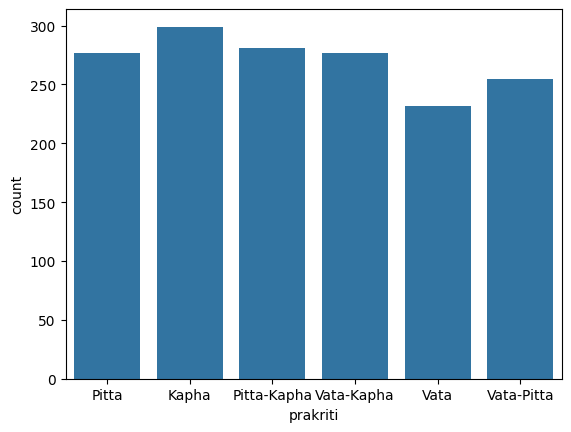

In [12]:
import seaborn as sns
sns.countplot(x='prakriti', data=df)


In [13]:
df.columns


Index(['patient_id', 'age', 'gender', 'stress_level', 'anxiety_level',
       'depression_score', 'maslow_physiological', 'maslow_safety',
       'maslow_social', 'maslow_esteem', 'maslow_self_actualization',
       'sleep_hours', 'exercise_frequency', 'diet_type', 'caffeine_intake',
       'screen_time_hours', 'prakriti', 'vikriti', 'herbs', 'diet_advice',
       'duration_days', 'improvement_score', 'side_effects'],
      dtype='object')

<Axes: xlabel='prakriti', ylabel='count'>

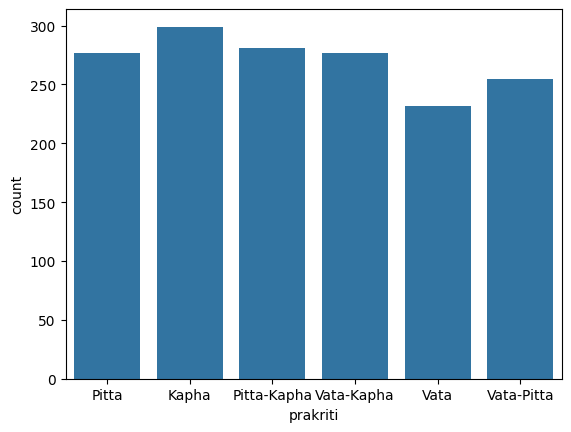

In [14]:
import seaborn as sns

sns.countplot(x='prakriti', data=df)


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


<Axes: >

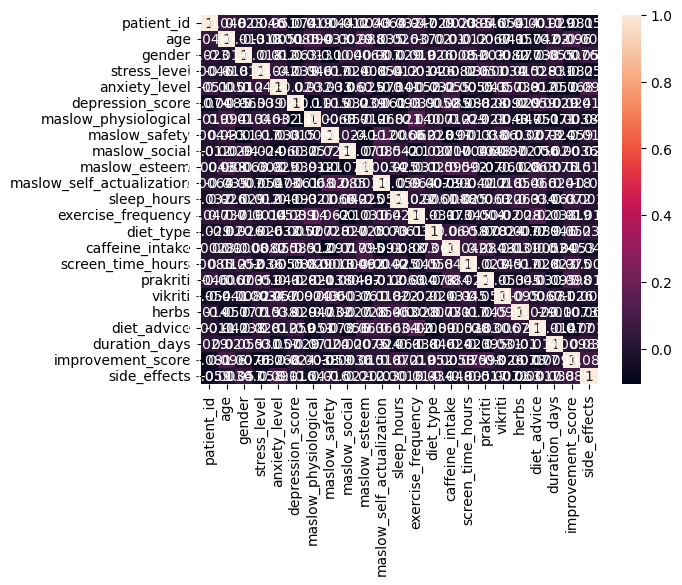

In [16]:
sns.heatmap(df.corr(), annot = True)

In [17]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

df['prakriti'] = LE.fit_transform(df['prakriti'])


In [18]:
df

,patient_id,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,...,diet_type,caffeine_intake,screen_time_hours,prakriti,vikriti,herbs,diet_advice,duration_days,improvement_score,side_effects
0,0,37,0,9,10,4,8,9,2,10,...,0,0,4,1,3,1,2,14,68,True
1,1,40,2,1,7,8,7,8,2,4,...,2,2,2,0,3,4,3,21,58,True
2,2,32,0,4,1,6,10,9,10,2,...,2,1,10,2,3,1,1,14,91,False
3,3,53,0,1,2,2,4,8,5,7,...,0,5,5,4,3,3,3,21,92,False
4,4,48,0,7,2,10,1,1,3,2,...,1,1,2,3,2,2,2,28,93,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1616,116,52,1,6,4,3,7,8,10,9,...,1,2,10,5,0,4,1,21,82,True
1617,117,69,1,2,1,1,9,4,6,6,...,0,3,8,1,2,3,0,15,80,True
1618,118,23,0,4,9,2,6,4,2,6,...,2,4,9,0,0,2,2,28,61,False
1619,119,66,0,5,8,10,7,1,3,10,...,1,4,6,2,0,4,1,21,58,False


In [19]:
df.prakriti.unique()

array([1, 0, 2, 4, 3, 5], dtype=int64)

<Axes: xlabel='prakriti', ylabel='count'>

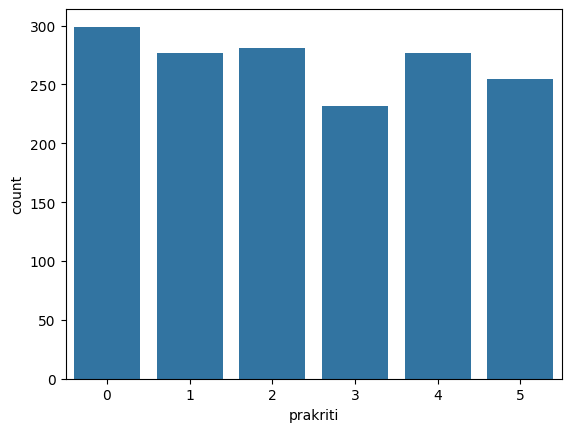

In [20]:
sns.countplot(x = 'prakriti', data = df)

In [21]:
X = df.drop('prakriti', axis = 1)
X

,patient_id,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,...,exercise_frequency,diet_type,caffeine_intake,screen_time_hours,vikriti,herbs,diet_advice,duration_days,improvement_score,side_effects
0,0,37,0,9,10,4,8,9,2,10,...,4,0,0,4,3,1,2,14,68,True
1,1,40,2,1,7,8,7,8,2,4,...,0,2,2,2,3,4,3,21,58,True
2,2,32,0,4,1,6,10,9,10,2,...,5,2,1,10,3,1,1,14,91,False
3,3,53,0,1,2,2,4,8,5,7,...,0,0,5,5,3,3,3,21,92,False
4,4,48,0,7,2,10,1,1,3,2,...,1,1,1,2,2,2,2,28,93,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1616,116,52,1,6,4,3,7,8,10,9,...,6,1,2,10,0,4,1,21,82,True
1617,117,69,1,2,1,1,9,4,6,6,...,1,0,3,8,2,3,0,15,80,True
1618,118,23,0,4,9,2,6,4,2,6,...,3,2,4,9,0,2,2,28,61,False
1619,119,66,0,5,8,10,7,1,3,10,...,2,1,4,6,0,4,1,21,58,False


In [22]:
y = df['prakriti']
y

0       1
1       0
2       2
3       4
4       3
       ..
1616    5
1617    1
1618    0
1619    2
1620    3
Name: prakriti, Length: 1621, dtype: int64

In [23]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 

In [24]:
x_train.shape

(1296, 22)

In [25]:
x_test.shape

(325, 22)

In [26]:
y_train.shape

(1296,)

In [27]:
y_test.shape

(325,)

In [28]:
precision = []
recall = []
fscore = []
accuracy = []
labels = ['Pitta', 'Kapha', 'Pitta-Kapha', 'Vata-Kapha', 'Vata',
       'Vata-Pitta']


In [29]:
def calculateMetrics(algorithm, predict, testY):
    
    testY = testY.astype('int')
    predict = predict.astype('int')
    
    p = precision_score(testY, predict, average='macro') * 100
    r = recall_score(testY, predict, average='macro') * 100
    f = f1_score(testY, predict, average='macro') * 100
    a = accuracy_score(testY, predict) * 100
    
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    
    print(algorithm + ' Accuracy: ' + str(a))
    print(algorithm + ' Precision : ' + str(p))
    print(algorithm + ' Recall: ' + str(r))
    print(algorithm + ' FSCORE: ' + str(f))
    
    # FIXED ORDER HERE
    report = classification_report(testY, predict, target_names=labels)
    print('\n', algorithm + " classification report\n", report)
    
    conf_matrix = confusion_matrix(testY, predict)
    
    plt.figure(figsize=(5,5))
    
    ax = sns.heatmap(
        conf_matrix,
        xticklabels=labels,
        yticklabels=labels,
        annot=True,
        fmt="g"
    )
    
    ax.set_ylim([0, len(labels)])
    
    plt.title(algorithm + " Confusion matrix")
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    
    plt.show()


KNN classifier_model trained and model weights saved.
KNeighborsClassifier Accuracy: 33.53846153846154
KNeighborsClassifier Precision : 33.582557171518324
KNeighborsClassifier Recall: 33.42536980551509
KNeighborsClassifier FSCORE: 33.3190394853852

 KNeighborsClassifier classification report
               precision    recall  f1-score   support

       Pitta       0.38      0.44      0.41        54
       Kapha       0.35      0.41      0.38        59
 Pitta-Kapha       0.28      0.27      0.28        55
  Vata-Kapha       0.34      0.26      0.30        42
        Vata       0.30      0.27      0.28        66
  Vata-Pitta       0.37      0.35      0.36        49

    accuracy                           0.34       325
   macro avg       0.34      0.33      0.33       325
weighted avg       0.33      0.34      0.33       325



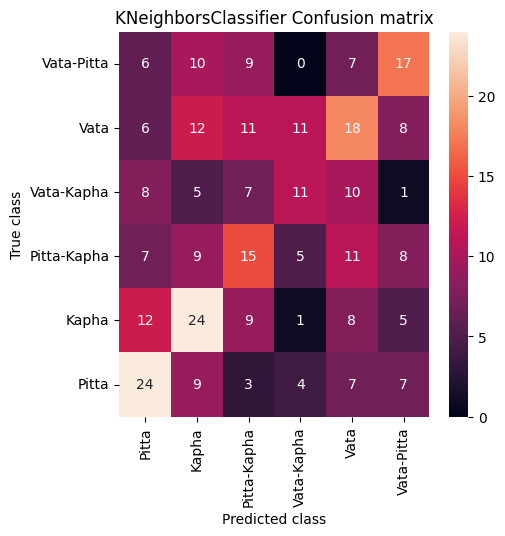

In [30]:
if os.path.exists('KNN_classifier.pkl'):
    classifier= joblib.load('KNN_weights.pkl')
    predict = classifier.predict(x_test)
    calculateMetrics("KNN Classifier", predict, y_test)
else:
    classifier = KNeighborsClassifier(n_neighbors=20)
    classifier.fit(x_train, y_train)
    predict=classifier.predict(x_test)
    joblib.dump(classifier, 'KNN_weights.pkl')
    print("KNN classifier_model trained and model weights saved.")
    calculateMetrics("KNeighborsClassifier", predict, y_test)

Decision Tree Accuracy: 96.0
Decision Tree Precision : 96.51436209655388
Decision Tree Recall: 96.10540432574331
Decision Tree FSCORE: 96.17222733911527

 Decision Tree classification report
               precision    recall  f1-score   support

       Pitta       0.94      0.94      0.94        54
       Kapha       1.00      0.95      0.97        59
 Pitta-Kapha       1.00      0.87      0.93        55
  Vata-Kapha       1.00      1.00      1.00        42
        Vata       0.90      1.00      0.95        66
  Vata-Pitta       0.94      1.00      0.97        49

    accuracy                           0.96       325
   macro avg       0.97      0.96      0.96       325
weighted avg       0.96      0.96      0.96       325



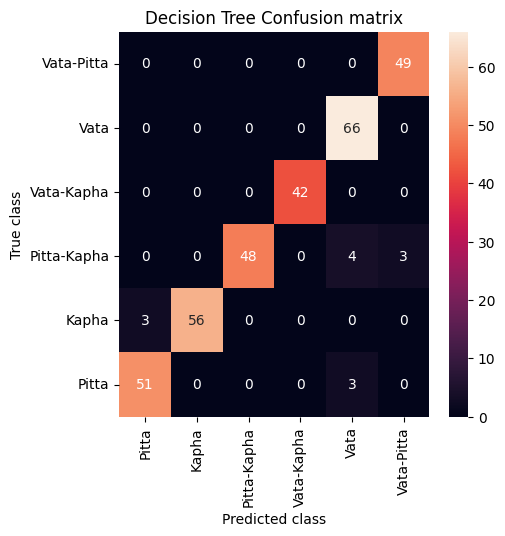

In [31]:

if os.path.exists('DT_weights.pkl'):
    classifier = joblib.load('DT_weights.pkl')
    predict = classifier.predict(x_test)
    calculateMetrics("Decision Tree", predict, y_test)
else:
    classifier = DecisionTreeClassifier()
    classifier.fit(x_train, y_train)
    predict = classifier.predict(x_test)
    joblib.dump(classifier, 'DT_weights.pkl')
    print("Decision Tree classifier_model trained and model weights saved.")
    calculateMetrics("Decision Tree", predict, y_test)


Ridge Regression Accuracy: 16.615384615384617
Ridge Regression Precision : 8.451790633608818
Ridge Regression Recall: 16.76205150781422
Ridge Regression FSCORE: 9.602487669765958

 Ridge Regression classification report
               precision    recall  f1-score   support

       Pitta       0.00      0.00      0.00        54
       Kapha       0.16      0.14      0.15        59
 Pitta-Kapha       0.17      0.73      0.27        55
  Vata-Kapha       0.18      0.14      0.16        42
        Vata       0.00      0.00      0.00        66
  Vata-Pitta       0.00      0.00      0.00        49

    accuracy                           0.17       325
   macro avg       0.08      0.17      0.10       325
weighted avg       0.08      0.17      0.09       325



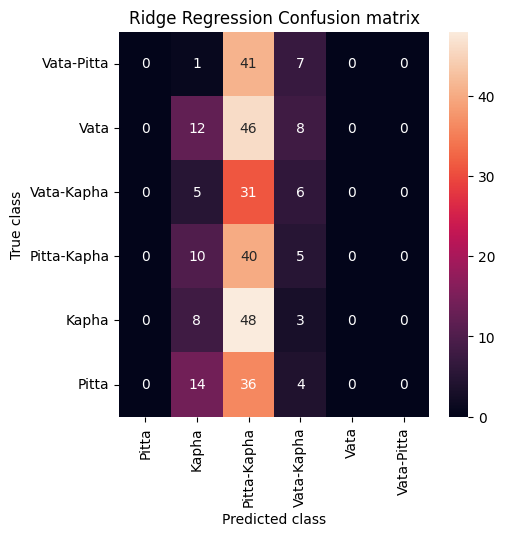

In [32]:
from sklearn.linear_model import Ridge
if os.path.exists('Ridge_weights.pkl'):
    regressor = joblib.load('Ridge_weights.pkl')
    predict = regressor.predict(x_test)
    calculateMetrics("Ridge Regression", predict, y_test)
else:
    regressor = Ridge()
    regressor.fit(x_train, y_train)
    predict = regressor.predict(x_test)
    joblib.dump(regressor, 'Ridge_weights.pkl')
    print("Ridge regression_model trained and model weights saved.")
    calculateMetrics("Ridge Regression", predict, y_test)


Random Forest Classifier Accuracy: 97.84615384615385
Random Forest Classifier Precision : 98.40182648401826
Random Forest Classifier Recall: 97.86195286195286
Random Forest Classifier FSCORE: 98.05555016902919

 Random Forest Classifier classification report
               precision    recall  f1-score   support

       Pitta       1.00      0.94      0.97        54
       Kapha       1.00      1.00      1.00        59
 Pitta-Kapha       1.00      0.93      0.96        55
  Vata-Kapha       1.00      1.00      1.00        42
        Vata       0.90      1.00      0.95        66
  Vata-Pitta       1.00      1.00      1.00        49

    accuracy                           0.98       325
   macro avg       0.98      0.98      0.98       325
weighted avg       0.98      0.98      0.98       325



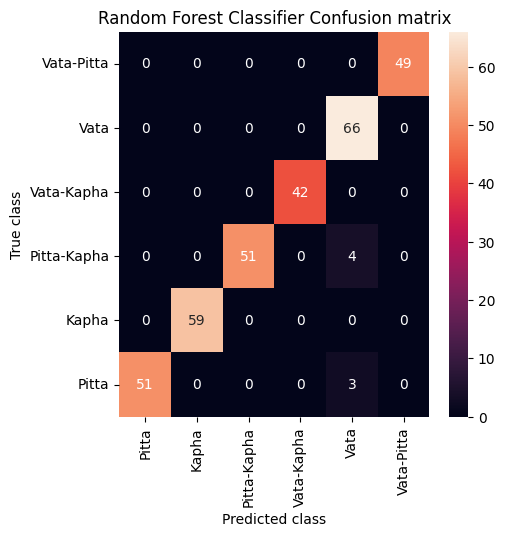

In [33]:
from sklearn.ensemble import RandomForestClassifier
if os.path.exists('RFC_weights.pkl'):
    rfc_classifier = joblib.load('RFC_weights.pkl')
    predict = rfc_classifier.predict(x_test)
    calculateMetrics("Random Forest Classifier", predict, y_test)
else:
    rfc_classifier = RandomForestClassifier()
    rfc_classifier.fit(x_train, y_train)
    predict = rfc_classifier.predict(x_test)
    joblib.dump(classifier, 'RFC_weights.pkl')
    print("Random Forest classifier_model trained and model weights saved.")
    calculateMetrics("Random Forest Classifier", predict, y_test)


In [34]:
testdata=pd.read_csv('Test data.csv')
testdata

,patient_id,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,...,exercise_frequency,diet_type,caffeine_intake,screen_time_hours,vikriti,herbs,diet_advice,duration_days,improvement_score,side_effects
0,0,37,0,9,10,4,8,9,2,10,...,4,0,0,4,3,1,2,14,68,True
1,1,40,2,1,7,8,7,8,2,4,...,0,2,2,2,3,4,3,21,58,True
2,2,32,0,4,1,6,10,9,10,2,...,5,2,1,10,3,1,1,14,91,False
3,3,53,0,1,2,2,4,8,5,7,...,0,0,5,5,3,3,3,21,92,False
4,4,48,0,7,2,10,1,1,3,2,...,1,1,1,2,2,2,2,28,93,True
5,5,21,0,1,7,9,5,10,4,5,...,7,1,0,9,2,0,0,21,89,False
6,6,41,0,7,3,10,2,10,4,8,...,7,2,1,6,2,3,1,28,72,False
7,7,40,2,8,3,2,8,10,4,6,...,5,2,3,5,2,4,1,21,59,False
8,8,19,1,10,7,0,9,3,4,10,...,5,1,4,3,0,4,0,21,54,False
9,9,22,0,8,4,4,10,5,9,1,...,1,2,3,9,2,3,2,15,63,True


In [35]:
pred=rfc_classifier.predict(testdata)
pred

array([1, 0, 2, 4, 3, 5, 0, 0, 2, 0, 0, 4, 3, 0, 3, 3, 3, 2, 4, 4],
      dtype=int64)

In [36]:
testdata['predicted']=[labels[i]for i in pred]
testdata

,patient_id,age,gender,stress_level,anxiety_level,depression_score,maslow_physiological,maslow_safety,maslow_social,maslow_esteem,...,diet_type,caffeine_intake,screen_time_hours,vikriti,herbs,diet_advice,duration_days,improvement_score,side_effects,predicted
0,0,37,0,9,10,4,8,9,2,10,...,0,0,4,3,1,2,14,68,True,Kapha
1,1,40,2,1,7,8,7,8,2,4,...,2,2,2,3,4,3,21,58,True,Pitta
2,2,32,0,4,1,6,10,9,10,2,...,2,1,10,3,1,1,14,91,False,Pitta-Kapha
3,3,53,0,1,2,2,4,8,5,7,...,0,5,5,3,3,3,21,92,False,Vata
4,4,48,0,7,2,10,1,1,3,2,...,1,1,2,2,2,2,28,93,True,Vata-Kapha
5,5,21,0,1,7,9,5,10,4,5,...,1,0,9,2,0,0,21,89,False,Vata-Pitta
6,6,41,0,7,3,10,2,10,4,8,...,2,1,6,2,3,1,28,72,False,Pitta
7,7,40,2,8,3,2,8,10,4,6,...,2,3,5,2,4,1,21,59,False,Pitta
8,8,19,1,10,7,0,9,3,4,10,...,1,4,3,0,4,0,21,54,False,Pitta-Kapha
9,9,22,0,8,4,4,10,5,9,1,...,2,3,9,2,3,2,15,63,True,Pitta
